In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


**DATA CLEANING**

In [4]:
df.isnull().sum()

# Rename target column for clarity
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)

In [5]:
df.describe()
df['default'].value_counts()

,count
default,
0,23364
1,6636


**CORRELATION HEATMAP**

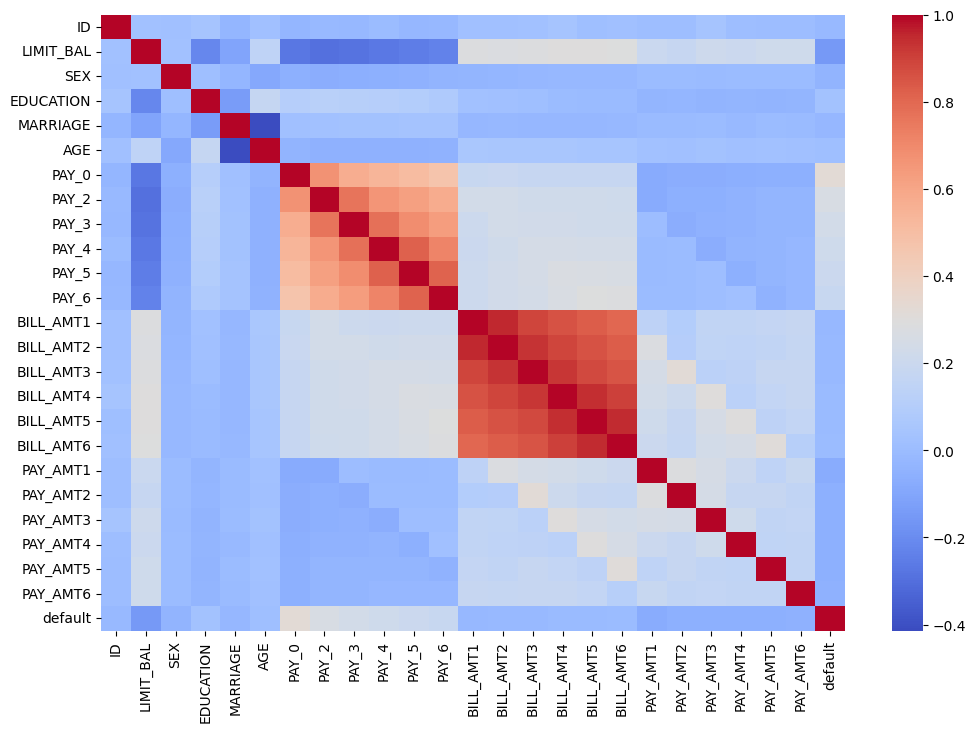

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

**Interpretation:**

* Variables like PAY_0, PAY_2 → strong positive correlation
* Some variables may show weak/no correlation
* Not all features matter equally
* Payment behavior dominates over demographics

**Action:**

Focus model/analysis on:

Payment history

Billing patterns

Ignore low-impact variables in decision-making

**KEY ANALYSIS**

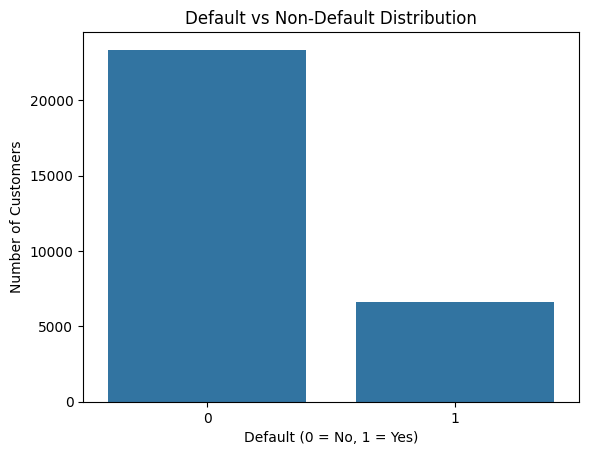

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='default', data=df)
plt.title("Default vs Non-Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

**INTERPRETATION**

The dataset shows that non-defaulters significantly outnumber defaulters, indicating a class imbalance. However, even a small proportion of defaulters can lead to substantial financial losses, making accurate identification of this group critical.

<Axes: xlabel='default', ylabel='AGE'>

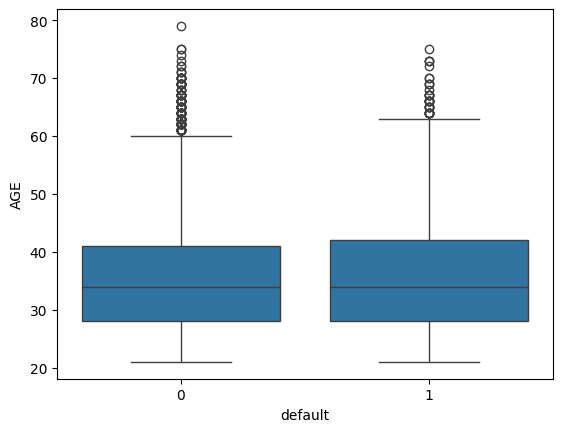

In [8]:
#default by age
sns.boxplot(x='default', y='AGE', data=df)

**Interpretation:**

*  If median age of defaulters is lower: Younger customers are riskier
*  If spread is wide: Risk exists across multiple age groups
*  Younger customers may have unstable income(less financial discipline)

**Action**

1. Add stricter approval criteria for younger applicants

2. Offer smaller initial credit limits

<Axes: xlabel='default', ylabel='LIMIT_BAL'>

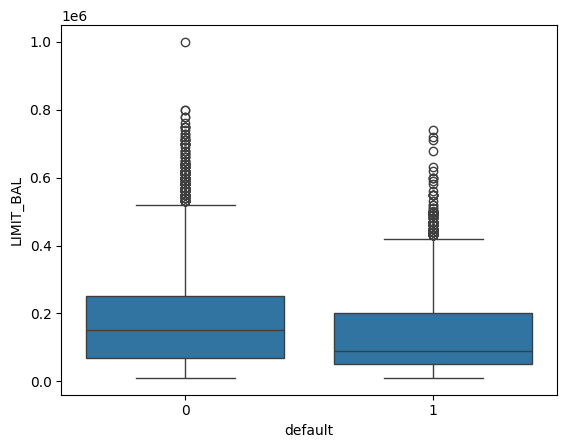

In [9]:
# default by credit limit
sns.boxplot(x='default', y='LIMIT_BAL', data=df)

**Interpretation:**

*  Defaulters usually have lower credit limits
*  Non-defaulters tend to have higher limits
*  Lower limit customers = financially weaker segment
*  Higher limit customers = trusted / stable profiles

**Action:**

1. Don’t aggressively lend to low-limit users
2. Introduce gradual credit increase system

<Axes: xlabel='PAY_0', ylabel='count'>

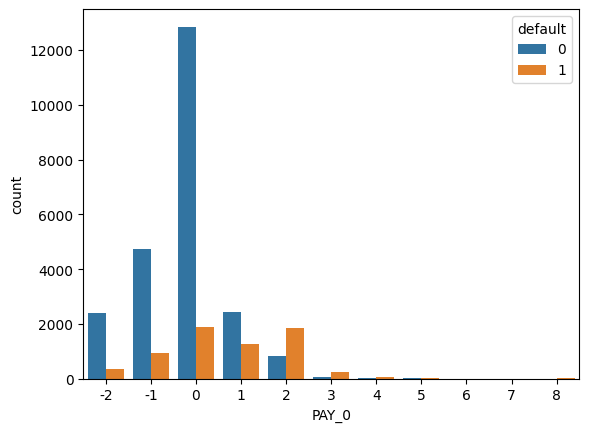

In [10]:
#impact of payment history
sns.countplot(x='PAY_0', hue='default', data=df)

**Interpretation:**

*  As payment delay increases, default rate increases sharply
*  Customers with on-time payments (PAY = 0) rarely default
*  Payment history is the STRONGEST predictor of default

**Action:**

Build early warning system:

1 missed payment → alert

2 delays → restrict credit

Prioritize this feature in risk scoring

In [11]:
# correlation with default
df.corr()['default'].sort_values(ascending=False)

,default
default,1.000000
PAY_0,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
EDUCATION,0.028006
AGE,0.013890
BILL_AMT6,-0.005372


In [14]:
df.to_csv("cleaned_credit_data.csv", index=False)